In [1]:
import sys, os

# Fix path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")

for p in [SRC_DIR, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"✅ SRC: {SRC_DIR}")
print(f"✅ ROOT: {PROJECT_ROOT}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load NASA dataset CSV
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "battery_data.csv")

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded NASA dataset: {df.shape}")
else:
    print("❌ battery_data.csv not found!")

plt.style.use("dark_background")
sns.set_palette("Set2")
print("✅ Ready!")


✅ SRC: c:\Users\HP\ecocharge\src
✅ ROOT: c:\Users\HP\ecocharge
✅ Loaded NASA dataset: (636, 9)
✅ Ready!


✅ SRC: c:\Users\HP\ecocharge\src
✅ ROOT: c:\Users\HP\ecocharge
✅ Imports complete
[preprocess] Loaded  636 rows, 9 columns.
  battery_id  cycle  voltage_measured  current_measured  temperature_measured  \
0      B0005      1            3.5298           -1.8187               32.5723   
1      B0005      2            3.5373           -1.8176               32.7252   
2      B0005      3            3.5437           -1.8165               32.6429   
3      B0005      4            3.5437           -1.8256               32.5149   
4      B0005      5            3.5423           -1.8261               32.3823   

   current_charge  voltage_charge     time  capacity  
0             0.0             0.0  3690.23  1.856487  
1             0.0             0.0  3672.34  1.846327  
2             0.0             0.0  3651.64  1.835349  
3             0.0             0.0  3631.56  1.835263  
4             0.0             0.0  3629.17  1.834646  

Shape: (636, 9)
Null values:
battery_id              0
cyc

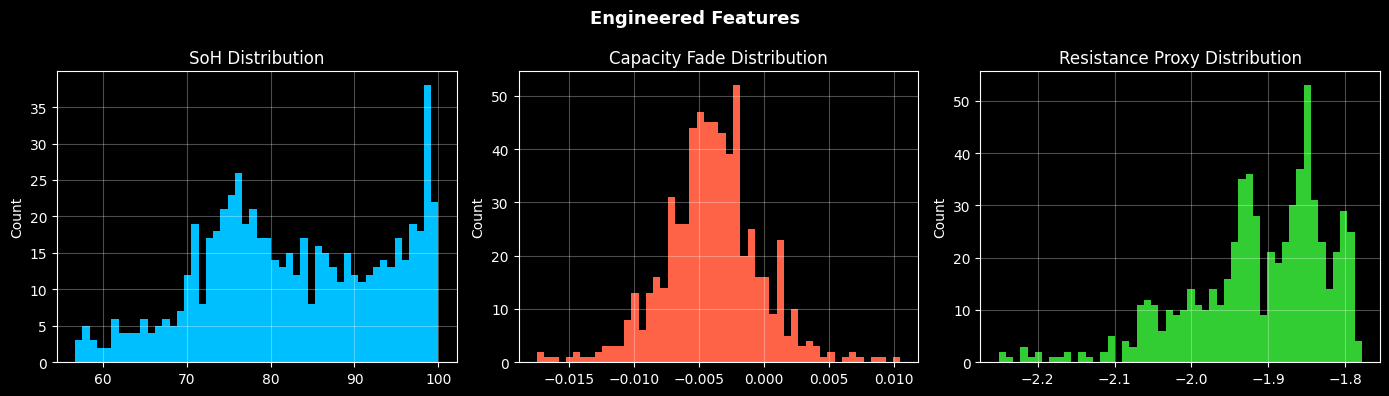

✅ Plot saved!
[preprocess] Scaler fitted and saved → c:\Users\HP\ecocharge\notebooks\../src\..\models\scaler.pkl
Scaled feature stats:
          cycle  voltage_measured  current_measured  temperature_measured  \
count  636.0000          636.0000          636.0000              636.0000   
mean     0.4776            0.5582            0.3433                0.5071   
std      0.2823            0.2801            0.2128                0.2213   
min      0.0000            0.0000            0.0000                0.0000   
25%      0.2335            0.3702            0.1807                0.3222   
50%      0.4731            0.5810            0.3081                0.5164   
75%      0.7126            0.8082            0.4697                0.7002   
max      1.0000            1.0000            1.0000                1.0000   

       current_charge  voltage_charge      time  
count           636.0           636.0  636.0000  
mean              0.0             0.0    0.3949  
std               0.0

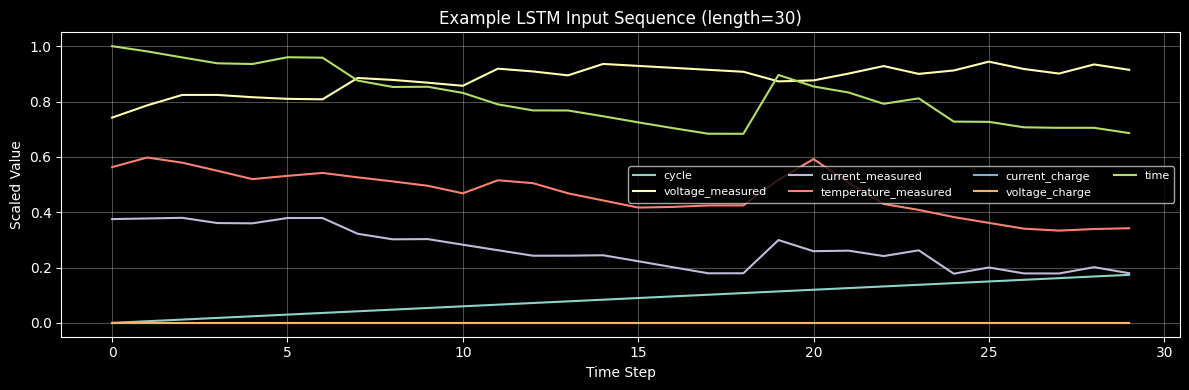

✅ Plot saved!
[preprocess] Split — Train: 361  Val: 77  Test: 78
Train : X (361, 30, 7)  y (361,)
Val   : X (77, 30, 7)  y (77,)
Test  : X (78, 30, 7)  y (78,)


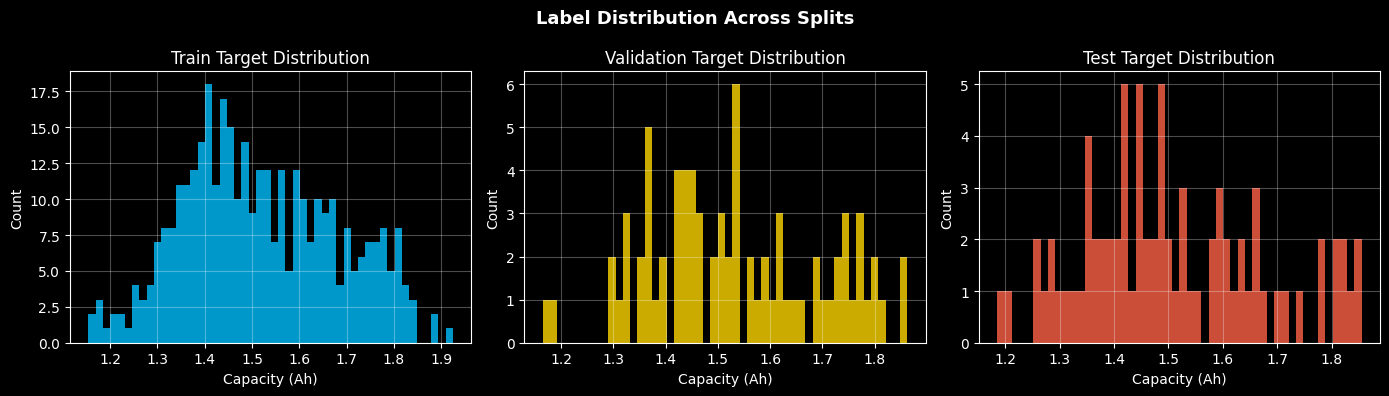

✅ Plot saved!
✅ Preprocessing complete!
   Sequences: X=(516, 30, 7), y=(516,)
   Next: run model_training.ipynb


In [3]:
# %% [markdown]
# # Notebook 02 — Data Preprocessing & Feature Engineering
# ### EcoCharge: EV Battery Degradation Prediction

# %% [markdown]
# ## 1. Imports

# %%
import sys, os

# Fix path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "results")

for p in [SRC_DIR, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✅ SRC: {SRC_DIR}")
print(f"✅ ROOT: {PROJECT_ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

from preprocess import (
    load_raw_data, clean_data, engineer_features,
    scale_features, create_sequences, split_data,
    FEATURE_COLS, TARGET_COL, SEQ_LENGTH,
)

plt.style.use('dark_background')
print("✅ Imports complete")

# %% [markdown]
# ## 2. Load Raw Data

# %%
df = load_raw_data()
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Null values:\n{df.isnull().sum()}")

# %% [markdown]
# ## 3. Clean Data

# %%
df_clean = clean_data(df.copy())
print(f"Before: {len(df):,} | After cleaning: {len(df_clean):,}")
print(f"Capacity range: {df_clean['capacity'].min():.4f} to {df_clean['capacity'].max():.4f}")

# %% [markdown]
# ## 4. Feature Engineering

# %%
df_feat = engineer_features(df_clean.copy())
print("New engineered columns: soh, capacity_fade, resistance_proxy")
print(df_feat[['battery_id','cycle','capacity','soh','capacity_fade','resistance_proxy']].head(10))

# %%
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df_feat['soh'],              bins=50, color='deepskyblue')
axes[0].set_title('SoH Distribution')
axes[1].hist(df_feat['capacity_fade'],    bins=50, color='tomato')
axes[1].set_title('Capacity Fade Distribution')
axes[2].hist(df_feat['resistance_proxy'], bins=50, color='limegreen')
axes[2].set_title('Resistance Proxy Distribution')
for ax in axes:
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
plt.suptitle('Engineered Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'preprocessing_features.png'), dpi=150)
plt.show()
print("✅ Plot saved!")

# %% [markdown]
# ## 5. Scaling

# %%
df_scaled, scaler = scale_features(df_feat.copy(), feature_cols=FEATURE_COLS, fit=True)
print("Scaled feature stats:")
print(df_scaled[FEATURE_COLS].describe().round(4))

# %% [markdown]
# ## 6. Create LSTM Sequences

# %%
X, y = create_sequences(df_scaled, feature_cols=FEATURE_COLS,
                        target_col=TARGET_COL, seq_length=SEQ_LENGTH)

print(f"\nX shape : {X.shape}  (samples, time_steps, features)")
print(f"y shape : {y.shape}  (samples,)")
print(f"\ny[0] (target capacity): {y[0]:.6f}")

# %%
fig, ax = plt.subplots(figsize=(12, 4))
for i, col in enumerate(FEATURE_COLS):
    ax.plot(X[0, :, i], label=col)
ax.set_title(f'Example LSTM Input Sequence (length={SEQ_LENGTH})', fontsize=12)
ax.set_xlabel('Time Step')
ax.set_ylabel('Scaled Value')
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'preprocessing_sequence.png'), dpi=150)
plt.show()
print("✅ Plot saved!")

# %% [markdown]
# ## 7. Train / Val / Test Split

# %%
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print(f"Train : X {X_train.shape}  y {y_train.shape}")
print(f"Val   : X {X_val.shape}  y {y_val.shape}")
print(f"Test  : X {X_test.shape}  y {y_test.shape}")

# %%
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, arr, title, color in zip(
    axes,
    [y_train, y_val, y_test],
    ['Train', 'Validation', 'Test'],
    ['deepskyblue', 'gold', 'tomato']
):
    ax.hist(arr, bins=50, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(f'{title} Target Distribution')
    ax.set_xlabel('Capacity (Ah)')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)

plt.suptitle('Label Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'preprocessing_splits.png'), dpi=150)
plt.show()
print("✅ Plot saved!")

# %%
print("✅ Preprocessing complete!")
print(f"   Sequences: X={X.shape}, y={y.shape}")
print("   Next: run model_training.ipynb")